In [108]:
import pandas as pd

# 1. 추출할 열 목록을 미리 리스트로 정의해 둡니다.
columns_to_select = [
     'ID', 'sex', 'age', 'DI1_dg','DI2_dg', 'DI2_ag', 'DI2_pr', 'DI2_pt',
      'DI2_2','DI5_dg', 'DI6_dg','DE1_dg','DE1_ag','DE1_pr','DE1_pt','HE_chol', 'HE_HDL_st2','HE_DM_HbA1c',
      'HE_TG', 'HE_LDL_drct', 'HE_HCHOL', 'HE_HTG','HE_BMI','HE_glu','HE_obe',"DN1_dg", "DI3_dg", "DJ2_dg" , "DC01_dg" , "DJ4_dg", "DL1_dg" , "DJ8_dg" , "DM4_dg", "DJ6_dg", "DH4_dg"]

# 2. 2020년부터 2025년까지 데이터 추출
for year in range(2020, 2025):
    # 연도의 뒤 2자리 추출 (예: 2020 -> '20', 2023 -> '23')
    year_suffix = str(year)[-2:] 
    
    # 불러올 파일명과 저장할 파일명 설정
    input_file = f"hn{year_suffix}_all.sas7bdat"
    output_file = f"{year}.csv"
    
    print(f"⏳ {year}년 데이터({input_file})를 처리 중입니다...")
    
    try:
        # 데이터 불러오기
        df = pd.read_sas(input_file)
        
        # 국민건강영양조사 데이터는 연도별로 일부 변수명이 다를 수 있으므로, 
        # 에러 방지를 위해 존재하는 열만 골라서 선택합니다.
        existing_cols = [col for col in columns_to_select if col in df.columns]
        df_select = df[existing_cols]
        
        # 이상 지질 혈증 조건 필터링 
        # (만약 특정 연도에 조건 열이 누락된 경우를 대비해 조건문 작성 전 확인)
        if all(col in df_select.columns for col in ["DI2_dg", "HE_HCHOL"]):
            df_select = df_select[
                (df_select["DI2_dg"] == 1) |
                (df_select["HE_HCHOL"] == 1)
            ]
        else:
            print(f"⚠️ {year}년 데이터에는 필터링 조건 열(DI2_dg 등) 중 일부가 없습니다. 필터링을 건너뜁니다.")
        
        # csv로 저장
        df_select.to_csv(output_file, index=False)
        print(f"✅ {output_file} 저장 완료! (총 {len(df_select)}행 추출됨)\n")
        
    except FileNotFoundError:
        print(f"❌ {input_file} 파일을 찾을 수 없습니다. 경로를 확인해 주세요.\n")
    except Exception as e:
        print(f"❌ {year}년 데이터 처리 중 알 수 없는 오류 발생: {e}\n")

print("🎉 모든 연도 데이터 추출 작업이 완료되었습니다!")

⏳ 2020년 데이터(hn20_all.sas7bdat)를 처리 중입니다...
✅ 2020.csv 저장 완료! (총 1748행 추출됨)

⏳ 2021년 데이터(hn21_all.sas7bdat)를 처리 중입니다...
✅ 2021.csv 저장 완료! (총 1811행 추출됨)

⏳ 2022년 데이터(hn22_all.sas7bdat)를 처리 중입니다...
✅ 2022.csv 저장 완료! (총 1753행 추출됨)

⏳ 2023년 데이터(hn23_all.sas7bdat)를 처리 중입니다...
✅ 2023.csv 저장 완료! (총 2004행 추출됨)

⏳ 2024년 데이터(hn24_all.sas7bdat)를 처리 중입니다...
✅ 2024.csv 저장 완료! (총 2148행 추출됨)

🎉 모든 연도 데이터 추출 작업이 완료되었습니다!


In [109]:
import pandas as pd

# 1. 기준이 되는 2020년 데이터 불러오기
try:
    df_merged = pd.read_csv("2020.csv")
    
    # 2020년 데이터의 컬럼명 변경 (ID, age, tins 제외)
    rename_dict_2020 = {}
    for col in df_merged.columns:
        if col not in ['ID', 'age', 'tins']:
            rename_dict_2020[col] = f"20_{col}"
            
    df_merged = df_merged.rename(columns=rename_dict_2020)
    print("✅ 2020년 데이터 기본 셋팅 완료!")

    # 2. 2021년부터 2024년까지 순차적으로 불러와서 병합하기
    for year in range(2021, 2025):
        year_suffix = str(year)[-2:] # '21', '22', '23', '24' 추출
        
        try:
            df_temp = pd.read_csv(f"{year}.csv")
            
            # age와 tins는 2020년 데이터 기준으로만 쓸 것이므로 제거
            cols_to_drop = [col for col in ['age', 'tins'] if col in df_temp.columns]
            df_temp = df_temp.drop(columns=cols_to_drop)
            
            # 컬럼명 변경 (ID 제외하고 앞에 연도 붙이기)
            rename_dict = {}
            for col in df_temp.columns:
                if col != 'ID':
                    rename_dict[col] = f"{year_suffix}_{col}"
            df_temp = df_temp.rename(columns=rename_dict)
            
            # ID 기준으로 병합 (어느 한 해에만 있는 ID도 누락되지 않도록 'outer' 조인 사용)
            df_merged = pd.merge(df_merged, df_temp, on='ID', how='outer')
            print(f"✅ {year}년 데이터 병합 완료!")
            
        except FileNotFoundError:
            print(f"⚠️ {year}.csv 파일이 없습니다. 해당 연도는 건너뜁니다.")

    # 3. 최종 병합된 데이터를 새로운 CSV 파일로 저장
    df_merged.to_csv("0new_2020_to_2024.csv", index=False)
    print(f"🎉 병합 완료! 총 {len(df_merged)}명의 데이터가 'merged_2020_to_2024.csv'로 저장되었습니다.")
    
except FileNotFoundError:
    print("❌ 2020.csv 파일을 찾을 수 없습니다. 파일이 생성되었는지 확인해 주세요.")

✅ 2020년 데이터 기본 셋팅 완료!
✅ 2021년 데이터 병합 완료!
✅ 2022년 데이터 병합 완료!
✅ 2023년 데이터 병합 완료!
✅ 2024년 데이터 병합 완료!
🎉 병합 완료! 총 9464명의 데이터가 'merged_2020_to_2024.csv'로 저장되었습니다.


In [110]:
import pandas as pd

# 1. 연도별 데이터 불러오기 및 'year' 열 추가
years = range(2020, 2025)
dfs = {}

for year in years:
    try:
        df = pd.read_csv(f"{year}.csv")
        df['year'] = year  # 데이터의 연도를 기록하는 열 추가
        dfs[year] = df
        print(f"✅ {year}.csv 로드 완료")
    except FileNotFoundError:
        print(f"⚠️ {year}.csv 파일이 없습니다. 건너뜁니다.")

if dfs:
    # 전체 데이터를 하나의 데이터프레임으로 세로 통합
    df_all = pd.concat(dfs.values(), ignore_index=True)
    
    # 2. 여러 연도에 중복으로 존재하는 ID 추출
    id_counts = df_all['ID'].value_counts()
    duplicate_ids = id_counts[id_counts > 1].index.tolist()
    print(f"📊 전체 ID 중 2회 이상 등장한 중복 ID 개수: {len(duplicate_ids)}개")

    # ----------------------------------------------------------------
    # [DF 1] 메인 데이터프레임 (세로 병합 + 중복 ID는 최신 연도만 유지)
    # ----------------------------------------------------------------
    # 연도 기준 오름차순 정렬 후 drop_duplicates(keep='last')를 적용하면 자동으로 가장 최신 연도 데이터만 남음
    df_main = df_all.sort_values('year').drop_duplicates(subset=['ID'], keep='last')
    # 보기 좋게 연도와 ID 기준으로 정렬 후 인덱스 재정의
    df_main = df_main.sort_values(['year', 'ID']).reset_index(drop=True)
    
    # ----------------------------------------------------------------
    # [DF 2] 중복 ID 데이터프레임 (중복 ID 전용 + 이전 방식의 가로 병합)
    # ----------------------------------------------------------------
    df_duplicates = None
    
    # 2020년 데이터 중 중복 ID에 해당하는 데이터만 필터링하여 기준으로 삼음
    if 2020 in dfs:
        df_2020_dup = dfs[2020][dfs[2020]['ID'].isin(duplicate_ids)].copy()
        df_2020_dup = df_2020_dup.drop(columns=['year'])  # 가로 병합을 위해 임시 year 열 제거
        
        # ID, age, tins를 제외한 모든 열 이름 앞에 '20_' 접두사 추가
        rename_dict_2020 = {col: f"20_{col}" for col in df_2020_dup.columns if col not in ['ID', 'age', 'tins']}
        df_duplicates = df_2020_dup.rename(columns=rename_dict_2020)
    else:
        # 2020년 데이터가 없을 경우를 대비한 빈 데이터프레임 틀 생성
        df_duplicates = pd.DataFrame(columns=['ID', 'age', 'tins'])

    # 2021년부터 2024년까지 순차적으로 가로 병합 진행
    for year in range(2021, 2025):
        if year in dfs:
            df_year_dup = dfs[year][dfs[year]['ID'].isin(duplicate_ids)].copy()
            df_year_dup = df_year_dup.drop(columns=['year'])
            
            # age와 tins는 2020년 기준을 유지하기 위해 다른 연도 데이터에서는 제거
            cols_to_drop = [col for col in ['age', 'tins'] if col in df_year_dup.columns]
            df_year_dup = df_year_dup.drop(columns=cols_to_drop)
            
            # ID를 제외한 열 이름 앞에 연도 접두사(예: '21_') 추가
            year_suffix = str(year)[-2:]
            rename_dict = {col: f"{year_suffix}_{col}" for col in df_year_dup.columns if col != 'ID'}
            df_year_dup = df_year_dup.rename(columns=rename_dict)
            
            # ID 기준 outer 조인으로 결합 (2020년엔 없지만 다른 해 사이에 중복인 경우도 누락 방지)
            df_duplicates = pd.merge(df_duplicates, df_year_dup, on='ID', how='outer')

    # 3. 두 개의 데이터프레임을 각각 CSV 파일로 저장
    df_main.to_csv("0new_merged_main_latest2.csv", index=False)
    df_duplicates.to_csv("0merged_duplicates_wide2.csv", index=False)
    
    print("\n🎉 모든 병합 및 분리 작업이 완료되었습니다!")
    print(f"💾 1. 메인 데이터 (세로 병합, 최신년도 유지): 'merged_main_latest.csv' ({len(df_main)}행)")
    print(f"💾 2. 중복 ID 데이터 (가로 병합 형식): 'merged_duplicates_wide.csv' ({len(df_duplicates)}행)")

else:
    print("❌ 불러온 데이터가 없어 작업을 진행하지 못했습니다.")

✅ 2020.csv 로드 완료
✅ 2021.csv 로드 완료
✅ 2022.csv 로드 완료
✅ 2023.csv 로드 완료
✅ 2024.csv 로드 완료
📊 전체 ID 중 2회 이상 등장한 중복 ID 개수: 0개

🎉 모든 병합 및 분리 작업이 완료되었습니다!
💾 1. 메인 데이터 (세로 병합, 최신년도 유지): 'merged_main_latest.csv' (9464행)
💾 2. 중복 ID 데이터 (가로 병합 형식): 'merged_duplicates_wide.csv' (0행)


In [141]:
import pandas as pd
import numpy as np

df = df_main.copy()
# ---------------------------------------------------------
# [가정] 현재 가지고 계신 데이터프레임 이름이 'df'라고 가정합니다.
# ---------------------------------------------------------

print("데이터 전처리를 시작합니다...\n")

# 1. Friedewald 공식을 이용한 LDL-C(HE_LDL_drct) 결측치 대체
# 조건: LDL이 결측치(NaN)이면서 중성지방(HE_TG)이 400 미만인 경우
missing_ldl = df['HE_LDL_drct'].isna()
valid_tg = df['HE_TG'] < 400 

df.loc[missing_ldl & valid_tg, 'HE_LDL_drct'] = (
    df['HE_chol'] - df['HE_HDL_st2'] - (df['HE_TG'] / 5)
)
print(f"✔️ Friedewald 공식 적용 완료: {missing_ldl.sum()}개의 결측치 중 조건(TG<400)에 맞는 값을 채웠습니다.")


# 2. 동반 질환에 따른 환자별 맞춤형 LDL-C 목표치(TARGET_LDL) 설정
conditions = [
    (df['DI5_dg'] == 1) | (df['DI6_dg'] == 1),      # ASCVD
    (df['DE1_dg'] == 1) | (df['HE_DM_HbA1c'] == 3)  # Diabetes
]

choices = [
    55,
    70
]

df['TARGET_LDL'] = np.select(
    conditions,
    choices,
    default=130
)

print("✔️ 환자별 맞춤형 LDL-C 목표치(TARGET_LDL) 열 생성 완료.")


# 3. 4개의 군(Group)으로 나누어 새로운 열('Patient_Group') 만들기
# 일단 모든 사람을 'Others (정상 또는 해당없음)'로 초기화
df['Patient_Group'] = 'Others'

# 1군: Control (치료 성공군)
# 조건: 치료 중(DI2_pt == 1) AND LDL 수치가 '자신의 맞춤 목표치' 미만
cond_control = (df['DI2_pt'] == 1) & (df['HE_LDL_drct'] < df['TARGET_LDL'])
df.loc[cond_control, 'Patient_Group'] = 'Control'

# 2군: Inadequately Treated (치료 중 미도달군 - 미충족 수요)
# 조건: 치료 중(DI2_pt == 1) AND LDL 수치가 '자신의 맞춤 목표치' 이상
cond_inadequate = (df['DI2_pt'] == 1) & (df['HE_LDL_drct'] >= df['TARGET_LDL'])
df.loc[cond_inadequate, 'Patient_Group'] = 'Inadequately Treated'

# 3군: Untreated (미치료 방치군 - 미충족 수요)
# 조건: 진단 받음(DI2_dg == 1) AND 치료 안함(DI2_pt == 0) AND LDL 수치가 목표치 이상
cond_untreated = (df['DI2_dg'] == 1) & (df['DI2_pt'] == 0) & (df['HE_LDL_drct'] >= df['TARGET_LDL'])
df.loc[cond_untreated, 'Patient_Group'] = 'Untreated'

df["LDL_130_Achieved"] = np.where(
    df["HE_LDL_drct"] < 130,
    1,   # 목표 달성
    0    # 목표 미달성
)

print("✔️ LDL-C <130 mg/dL 달성 여부(LDL_130_Achieved) 생성 완료.")
# 4. 결과 확인 및 저장
print("\n각 그룹별 환자 수:")
print(df['Patient_Group'].value_counts())

# 전처리된 데이터를 새로운 CSV 파일로 저장
# 주석(#)을 풀면 실제 파일로 저장됩니다.
df.to_csv('00NNEEWW_KNHANES_lipid_grouped.csv', index=False, encoding='utf-8-sig')
print("\n데이터 분류가 완료되었습니다. 🚀")

데이터 전처리를 시작합니다...

✔️ Friedewald 공식 적용 완료: 3110개의 결측치 중 조건(TG<400)에 맞는 값을 채웠습니다.
✔️ 환자별 맞춤형 LDL-C 목표치(TARGET_LDL) 열 생성 완료.
✔️ LDL-C <130 mg/dL 달성 여부(LDL_130_Achieved) 생성 완료.

각 그룹별 환자 수:
Patient_Group
Control                 4062
Others                  2809
Inadequately Treated    1757
Untreated                836
Name: count, dtype: int64

데이터 분류가 완료되었습니다. 🚀


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [142]:
# =========================================================
# 0. 데이터 복사
# =========================================================
df = pd.read_csv('00NNEEWW_KNHANES_lipid_grouped.csv')

analysis_df = df.copy()

analysis_df = analysis_df.replace(
    [np.inf, -np.inf],
    np.nan
)


# =========================================================
# 1. 질환 관련 변수 이진화
# 1이면 1, 그 외 0/8/9/99/999/결측치는 모두 0
# =========================================================
import numpy as np
import pandas as pd

binary_disease_cols = [
    "DI5_dg",
    "DI6_dg",
    "DI1_dg",
    "DI3_dg",
    "DJ2_dg",
    "DC01_dg",
    "DJ4_dg",
    "DL1_dg",
    "DJ8_dg",
    "DM4_dg",
    "DJ6_dg",
    "DH4_dg",
    "DE1_pr",
    "DE1_pt"
]

for col in binary_disease_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(
            analysis_df[col],
            errors="coerce"
        )

        analysis_df[col] = analysis_df[col].where(
            analysis_df[col].isin([0, 1]),
            np.nan
        )



# =========================================================
# 2. ASCVD 및 Diabetes 변수 생성
# =========================================================

# ASCVD:
# DI5_dg 또는 DI6_dg가 1인 경우
analysis_df["ASCVD"] = (
    (analysis_df["DI5_dg"] == 1) |
    (analysis_df["DI6_dg"] == 1)
).astype(int)


# Diabetes mellitus(당뇨병):
# DE1_dg, HE_DM_HbA1c 중 하나라도 1인 경우
analysis_df["Diabetes"] = (
    (analysis_df["DE1_dg"] == 1) |
    (analysis_df["HE_DM_HbA1c"] == 3)
).astype(int)


# =========================================================
# 3. Disease 문자열 변수 생성
# =========================================================
conditions = [
    (
        (analysis_df["ASCVD"] == 1) &
        (analysis_df["Diabetes"] == 1)
    ),
    (
        (analysis_df["ASCVD"] == 1) &
        (analysis_df["Diabetes"] == 0)
    ),
    (
        (analysis_df["ASCVD"] == 0) &
        (analysis_df["Diabetes"] == 1)
    )
]

choices = [
    "ASCVD + Diabetes",
    "ASCVD",
    "Diabetes"
]

analysis_df["Disease"] = np.select(
    conditions,
    choices,
    default="Others"
)

print("Disease 분포:")
print(analysis_df["Disease"].value_counts(dropna=False))

Disease 분포:
Disease
Others              6635
Diabetes            2521
ASCVD                167
ASCVD + Diabetes     141
Name: count, dtype: int64


In [144]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import shap
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# =========================================================
# 1. Logistic regression 함수
# Logistic regression에서는 결측치를 대체
# =========================================================

def run_logistic_analysis(
    data,
    outcome_col,
    analysis_name,
    predictor_cols,
    continuous_cols=None
):
    """
    수행 내용

    1. 목표 달성률 및 미달성률
    2. Multivariable logistic regression(다변량 로지스틱 회귀분석)
       - OR
       - 95% CI
       - p-value

    Outcome:
    0 = 목표 달성
    1 = 목표 미달성

    결측치 처리:
    - 연속형 변수: 중앙값 대체
    - 이진형 변수: 최빈값 대체
    """

    continuous_cols = continuous_cols or []

    model_df = data.copy()

    # Outcome 숫자형 변환
    model_df[outcome_col] = pd.to_numeric(
        model_df[outcome_col],
        errors="coerce"
    )

    # Outcome 결측 제거
    model_df = model_df.dropna(
        subset=[outcome_col]
    ).copy()

    model_df[outcome_col] = (
        model_df[outcome_col].astype(int)
    )

    # 실제 존재하는 Predictor만 사용
    predictor_cols = [
        col for col in predictor_cols
        if col in model_df.columns
    ]

    continuous_cols = [
        col for col in continuous_cols
        if col in predictor_cols
    ]

    # Predictor와 Outcome 생성
    X = model_df[predictor_cols].copy()
    y = model_df[outcome_col].copy()

    # 숫자형 변환
    for col in X.columns:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

    # 전부 결측인 변수 제거
    all_missing_cols = [
        col for col in X.columns
        if X[col].isna().all()
    ]

    if all_missing_cols:
        print(
            "Logistic regression에서 전부 결측이라 제외된 변수:",
            all_missing_cols
        )

        X = X.drop(
            columns=all_missing_cols
        )

    # 값이 한 종류뿐인 변수 제거
    constant_cols = [
        col for col in X.columns
        if X[col].nunique(dropna=True) <= 1
    ]

    if constant_cols:
        print(
            "Logistic regression에서 상수라 제외된 변수:",
            constant_cols
        )

        X = X.drop(
            columns=constant_cols
        )

    continuous_cols = [
        col for col in continuous_cols
        if col in X.columns
    ]

    # 연속형이 아닌 변수
    other_cols = [
        col for col in X.columns
        if col not in continuous_cols
    ]

    # =====================================================
    # Logistic regression용 결측치 처리
    # =====================================================

    if continuous_cols:

        continuous_imputer = SimpleImputer(
            strategy="median"
        )

        X[continuous_cols] = (
            continuous_imputer.fit_transform(
                X[continuous_cols]
            )
        )

    if other_cols:

        other_imputer = SimpleImputer(
            strategy="most_frequent"
        )

        X[other_cols] = (
            other_imputer.fit_transform(
                X[other_cols]
            )
        )

    # =====================================================
    # 연속형 변수 표준화
    # OR은 연속형 변수 1 SD 증가당 OR
    # =====================================================

    if continuous_cols:

        scaler = StandardScaler()

        X[continuous_cols] = scaler.fit_transform(
            X[continuous_cols]
        )

    X = X.astype(float)

    # 다시 상수 변수 제거
    constant_cols_after = [
        col for col in X.columns
        if X[col].nunique(dropna=True) <= 1
    ]

    if constant_cols_after:

        X = X.drop(
            columns=constant_cols_after
        )

    # =====================================================
    # 목표 달성률
    # =====================================================

    total_n = len(y)
    achieved_n = int((y == 0).sum())
    not_achieved_n = int((y == 1).sum())

    achieved_rate = (
        achieved_n / total_n * 100
        if total_n > 0
        else np.nan
    )

    not_achieved_rate = (
        not_achieved_n / total_n * 100
        if total_n > 0
        else np.nan
    )

    achievement_result = pd.DataFrame({
        "Group": [
            "Achieved",
            "Not achieved"
        ],
        "N": [
            achieved_n,
            not_achieved_n
        ],
        "Percent": [
            achieved_rate,
            not_achieved_rate
        ]
    })

    print("\n" + "=" * 80)
    print(analysis_name)
    print("=" * 80)

    print(f"분석 대상자 수: {total_n:,}")

    print(
        f"목표 달성: {achieved_n:,}명 "
        f"({achieved_rate:.2f}%)"
    )

    print(
        f"목표 미달성: {not_achieved_n:,}명 "
        f"({not_achieved_rate:.2f}%)"
    )

    # =====================================================
    # Multivariable logistic regression
    # =====================================================

    X_logit = sm.add_constant(
        X,
        has_constant="add"
    )

    try:

        logistic_model = sm.GLM(
            y,
            X_logit,
            family=sm.families.Binomial()
        ).fit()

        conf_int = logistic_model.conf_int()

        logistic_result = pd.DataFrame({
            "Feature": logistic_model.params.index,
            "Coefficient": logistic_model.params.values,
            "OR": np.exp(
                logistic_model.params.values
            ),
            "CI_95_Lower": np.exp(
                conf_int[0].values
            ),
            "CI_95_Upper": np.exp(
                conf_int[1].values
            ),
            "p_value": logistic_model.pvalues.values
        })

        logistic_result = logistic_result[
            logistic_result["Feature"] != "const"
        ].copy()

        logistic_result["Direction"] = np.where(
            logistic_result["OR"] > 1,
            "미달성 오즈 증가",
            "미달성 오즈 감소"
        )

        logistic_result = logistic_result.sort_values(
            ["p_value", "OR"],
            ascending=[True, False]
        ).reset_index(drop=True)

        print(
            "\nMultivariable logistic regression:"
        )

        print(
            logistic_result[
                [
                    "Feature",
                    "OR",
                    "CI_95_Lower",
                    "CI_95_Upper",
                    "p_value",
                    "Direction"
                ]
            ].round(4)
        )

    except Exception as e:

        logistic_model = None
        logistic_result = None

        print(
            "\nLogistic regression 실행 오류:"
        )

        print(e)

    return {
        "achievement": achievement_result,
        "logistic_result": logistic_result,
        "logistic_model": logistic_model,
        "X_logistic": X,
        "y": y
    }


# =========================================================
# 2. Random forest 및 SHAP 함수
# NaN을 대체하지 않고 그대로 사용
# =========================================================

def run_rf_shap_analysis(
    data,
    outcome_col,
    analysis_name,
    predictor_cols,
    run_shap=True,
    random_state=42
):
    """
    수행 내용

    1. Random forest(랜덤포레스트) 변수 중요도
    2. SHAP 변수 중요도
    3. SHAP summary plot

    Outcome:
    0 = 목표 달성
    1 = 목표 미달성

    결측치 처리:
    - NaN을 대체하지 않고 그대로 유지
    """

    model_df = data.copy()

    # Outcome 숫자형 변환
    model_df[outcome_col] = pd.to_numeric(
        model_df[outcome_col],
        errors="coerce"
    )

    # Outcome 결측 제거
    model_df = model_df.dropna(
        subset=[outcome_col]
    ).copy()

    model_df[outcome_col] = (
        model_df[outcome_col].astype(int)
    )

    # 실제 존재하는 Predictor만 사용
    predictor_cols = [
        col for col in predictor_cols
        if col in model_df.columns
    ]

    X = model_df[predictor_cols].copy()
    y = model_df[outcome_col].copy()

    # 숫자형 변환
    for col in X.columns:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

    # 전부 결측인 변수 제거
    all_missing_cols = [
        col for col in X.columns
        if X[col].isna().all()
    ]

    if all_missing_cols:
        print(
            "RF에서 전부 결측이라 제외된 변수:",
            all_missing_cols
        )

        X = X.drop(
            columns=all_missing_cols
        )

    # 결측값을 제외하고 값이 한 종류뿐인 변수 제거
    constant_cols = [
        col for col in X.columns
        if X[col].nunique(dropna=True) <= 1
    ]

    if constant_cols:
        print(
            "RF에서 상수라 제외된 변수:",
            constant_cols
        )

        X = X.drop(
            columns=constant_cols
        )

    X = X.astype(float)

    print("\n" + "=" * 80)
    print(analysis_name)
    print("=" * 80)

    print(f"분석 대상자 수: {len(y):,}")

    print("\nPredictor별 결측치 수:")

    print(
        X.isna()
        .sum()
        .sort_values(ascending=False)
    )

    # =====================================================
    # Random forest
    # =====================================================

    rf_model = RandomForestClassifier(
        n_estimators=1000,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1
    )

    try:

        rf_model.fit(
            X,
            y
        )

    except ValueError as e:

        raise ValueError(
            "\n현재 설치된 scikit-learn의 "
            "RandomForestClassifier가 NaN을 직접 처리하지 "
            "못하는 버전일 수 있습니다.\n"
            "먼저 아래 코드로 버전을 확인하십시오.\n\n"
            "import sklearn\n"
            "print(sklearn.__version__)\n\n"
            f"원래 오류 메시지:\n{e}"
        )

    rf_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf_model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    print(
        "\nRandom forest 변수 중요도:"
    )

    print(
        rf_importance
        .head(20)
        .round(4)
    )

    # =====================================================
    # SHAP
    # =====================================================

    shap_importance = None
    positive_shap_values = None
    X_shap = None

    if run_shap:

        sample_n = min(
            1000,
            len(X)
        )

        X_shap = X.sample(
            n=sample_n,
            random_state=random_state
        )

        explainer = shap.TreeExplainer(
            rf_model
        )

        shap_values = explainer.shap_values(
            X_shap
        )

        # SHAP 버전별 출력 형태 처리
        if isinstance(shap_values, list):

            positive_shap_values = (
                shap_values[1]
            )

        elif (
            isinstance(shap_values, np.ndarray)
            and shap_values.ndim == 3
        ):

            positive_shap_values = (
                shap_values[:, :, 1]
            )

        else:

            positive_shap_values = shap_values

        shap_importance = pd.DataFrame({
            "Feature": X.columns,
            "Mean_Abs_SHAP": np.abs(
                positive_shap_values
            ).mean(axis=0)
        }).sort_values(
            "Mean_Abs_SHAP",
            ascending=False
        ).reset_index(drop=True)

        print(
            "\nSHAP 변수 중요도:"
        )

        print(
            shap_importance
            .head(20)
            .round(4)
        )

        shap.summary_plot(
            positive_shap_values,
            X_shap,
            feature_names=X.columns,
            max_display=20,
            show=True
        )

    return {
        "rf_importance": rf_importance,
        "rf_model": rf_model,
        "shap_importance": shap_importance,
        "shap_values": positive_shap_values,
        "X_shap": X_shap,
        "X_rf": X,
        "y": y
    }


# =========================================================
# 3. 분석 변수 설정
# =========================================================

# Outcome과 직접 관련된 지질 관련 변수 제외
lipid_cols = [
    "HE_chol",
    "HE_HDL_st2",
    "HE_TG",
    "HE_LDL_drct",
    "HE_HCHOL"
]

# 이상지질혈증 관련 변수 전체 제외
di2_cols = [
    col for col in analysis_df.columns
    if col.startswith("DI2")
]


# 기본 후보 Predictor
base_predictors = [
    "sex",
    "age",
    "DI5_dg",
    "DI6_dg",
    "DI1_dg",
    "DI3_dg",
    "DJ2_dg",
    "DC01_dg",
    "DJ4_dg",
    "DL1_dg",
    "DJ8_dg",
    "DM4_dg",
    "DJ6_dg",
    "DH4_dg",
    "DE1_dg",
    "DE1_pt",
    "DE1_pr",
    "HE_BMI",
    "HE_glu",
    "HE_DM_HbA1c"
]

# 연속형 변수
continuous_cols = [
    "age",
    "HE_BMI",
    "HE_glu",
    "HE_DM_HbA1c"
    #"DE1_ag"
]

In [145]:
# =========================================================
# Analysis 1 분석 대상 생성
# =========================================================

analysis1_df = analysis_df[
    analysis_df["Patient_Group"].isin(
        [
            "Control",
            "Inadequately Treated"
        ]
    )
].copy()


# Outcome 생성
# 0 = Control
# 1 = Inadequately Treated
analysis1_df["Outcome_NotAchieved"] = np.where(
    analysis1_df["Patient_Group"]
    == "Inadequately Treated",
    1,
    0
)


# Analysis 1에서는 DI5_dg, DI6_dg 제외
analysis1_predictors = [
    col for col in base_predictors
    if col not in [
        "DI2_dg",
        "DI2_pt"
    ]
    and col not in lipid_cols
    and col not in di2_cols
]


# =========================================================
# Logistic regression 실행
# 결측치는 함수 내부에서 대체됨
# =========================================================

result_analysis1_logistic = run_logistic_analysis(
    data=analysis1_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 1: Logistic regression "
        "- Control vs Inadequately Treated"
    ),
    predictor_cols=analysis1_predictors,
    continuous_cols=continuous_cols
)


Analysis 1: Logistic regression - Control vs Inadequately Treated
분석 대상자 수: 5,819
목표 달성: 4,062명 (69.81%)
목표 미달성: 1,757명 (30.19%)

Multivariable logistic regression:
        Feature       OR  CI_95_Lower  CI_95_Upper  p_value  Direction
0   HE_DM_HbA1c   3.0995       2.7064       3.5498   0.0000  미달성 오즈 증가
1        DI6_dg  31.9442      19.5697      52.1435   0.0000  미달성 오즈 증가
2        DI5_dg   9.4958       5.0319      17.9198   0.0000  미달성 오즈 증가
3        HE_glu   1.1648       1.0836       1.2521   0.0000  미달성 오즈 증가
4        DE1_dg   1.5045       1.2197       1.8558   0.0001  미달성 오즈 증가
5        DI1_dg   0.7586       0.6520       0.8827   0.0004  미달성 오즈 감소
6        DE1_pt   0.1364       0.0302       0.6168   0.0097  미달성 오즈 감소
7           age   0.9084       0.8427       0.9792   0.0121  미달성 오즈 감소
8           sex   1.1645       1.0067       1.3471   0.0403  미달성 오즈 증가
9        HE_BMI   1.0635       0.9908       1.1416   0.0885  미달성 오즈 증가
10       DE1_pr   4.2400       0.7573      23.7382   


Analysis 1: Random forest and SHAP - Control vs Inadequately Treated
분석 대상자 수: 5,819

Predictor별 결측치 수:
DC01_dg        4519
DE1_pr         3946
DE1_pt         3946
DJ2_dg         2649
DI5_dg         2648
DI6_dg         2648
DM4_dg         2648
DI3_dg         2645
DH4_dg         1744
DJ6_dg         1744
DJ8_dg          444
DJ4_dg          444
DL1_dg          444
HE_DM_HbA1c     171
HE_BMI          131
DE1_dg            0
age               0
DI1_dg            0
HE_glu            0
sex               0
dtype: int64

Random forest 변수 중요도:
        Feature  Importance
0   HE_DM_HbA1c      0.2630
1        HE_glu      0.1257
2        DE1_pr      0.0981
3        DE1_pt      0.0938
4        HE_BMI      0.0869
5        DI6_dg      0.0863
6        DE1_dg      0.0850
7           age      0.0646
8        DI5_dg      0.0220
9        DI1_dg      0.0135
10          sex      0.0111
11       DM4_dg      0.0073
12       DJ6_dg      0.0073
13       DH4_dg      0.0068
14       DJ2_dg      0.0063
15       DJ

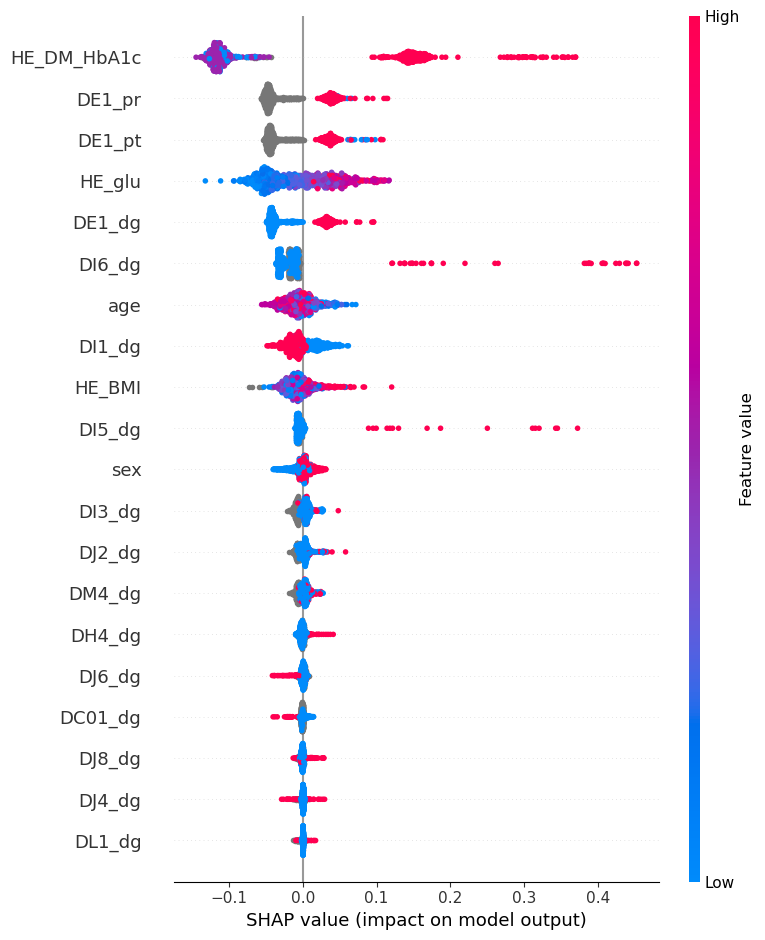

In [146]:
# =========================================================
# Random forest 및 SHAP 실행
# NaN은 그대로 유지
# =========================================================

result_analysis1_rf_shap = run_rf_shap_analysis(
    data=analysis1_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 1: Random forest and SHAP "
        "- Control vs Inadequately Treated"
    ),
    predictor_cols=analysis1_predictors,
    run_shap=True,
    random_state=42
)

In [136]:
# =========================================================
# Analysis 2-1 분석 대상 생성
# ASCVD == 1
# 0 = LDL-C <55 mg/dL 목표 달성
# 1 = LDL-C >=55 mg/dL 목표 미달성
# =========================================================

analysis2_1_df = analysis_df[
    (analysis_df["Di"] == 1) &
    (analysis_df["HE_LDL_drct"].notna())
].copy()


analysis2_1_df["Outcome_NotAchieved"] = np.where(
    analysis2_1_df["HE_LDL_drct"] >= 55,
    1,
    0
)


# Analysis 2-1 Predictor 설정
analysis2_1_predictors = [
    col for col in base_predictors
    if col not in [
        "DI5_dg",
        "DI6_dg",
    ]
    and col not in lipid_cols
    and col not in di2_cols
]

In [137]:
# =========================================================
# Analysis 2-1 Logistic regression
# 결측치는 함수 내부에서 대체
# 연속형 변수는 표준화
# =========================================================

result_analysis2_1_logistic = run_logistic_analysis(
    data=analysis2_1_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 2-1: ASCVD군 LDL-C <55 mg/dL 미달성 "
        "- Logistic regression"
    ),
    predictor_cols=analysis2_1_predictors,
    continuous_cols=continuous_cols
)


Analysis 2-1: ASCVD군 LDL-C <55 mg/dL 미달성 - Logistic regression
분석 대상자 수: 296
목표 달성: 41명 (13.85%)
목표 미달성: 255명 (86.15%)

Multivariable logistic regression:
        Feature            OR  CI_95_Lower  CI_95_Upper  p_value  Direction
0        HE_glu  6.656000e-01       0.4447       0.9964   0.0480  미달성 오즈 감소
1        DI1_dg  3.752000e-01       0.1409       0.9988   0.0497  미달성 오즈 감소
2           sex  2.004300e+00       0.8925       4.5007   0.0921  미달성 오즈 증가
3           age  1.212200e+00       0.8399       1.7496   0.3039  미달성 오즈 증가
4        DI3_dg  2.014300e+00       0.4447       9.1245   0.3636  미달성 오즈 증가
5        DJ2_dg  5.275000e-01       0.1254       2.2200   0.3831  미달성 오즈 감소
6        DJ6_dg  2.617900e+00       0.2955      23.1933   0.3872  미달성 오즈 증가
7        DE1_dg  1.425800e+00       0.4756       4.2748   0.5266  미달성 오즈 증가
8       DC01_dg  6.047000e-01       0.1099       3.3262   0.5631  미달성 오즈 감소
9        HE_BMI  1.117500e+00       0.7574       1.6487   0.5757  미달성 오즈 증가
10      

/var/folders/7w/hw9rw9p16vn9z7jggjqtl6_w0000gn/T/ipykernel_11082/1359608434.py:260: RuntimeWarning: overflow encountered in exp
  "CI_95_Upper": np.exp(



Analysis 2-1: ASCVD군 LDL-C <55 mg/dL 미달성 - Random forest and SHAP
분석 대상자 수: 296

Predictor별 결측치 수:
DC01_dg        195
DE1_pr         186
DE1_pt         186
DJ6_dg         101
DH4_dg         101
HE_DM_HbA1c      8
HE_BMI           4
HE_glu           0
DE1_dg           0
sex              0
age              0
DJ8_dg           0
DL1_dg           0
DJ4_dg           0
DJ2_dg           0
DI3_dg           0
DI1_dg           0
DM4_dg           0
dtype: int64

Random forest 변수 중요도:
        Feature  Importance
0        HE_BMI      0.1938
1           age      0.1602
2        HE_glu      0.1482
3           sex      0.0992
4        DI1_dg      0.0726
5        DJ4_dg      0.0434
6        DM4_dg      0.0420
7        DH4_dg      0.0410
8   HE_DM_HbA1c      0.0355
9        DJ6_dg      0.0346
10      DC01_dg      0.0286
11       DE1_pt      0.0269
12       DE1_pr      0.0264
13       DE1_dg      0.0204
14       DJ8_dg      0.0138
15       DI3_dg      0.0075
16       DJ2_dg      0.0058
17       DL1_dg   

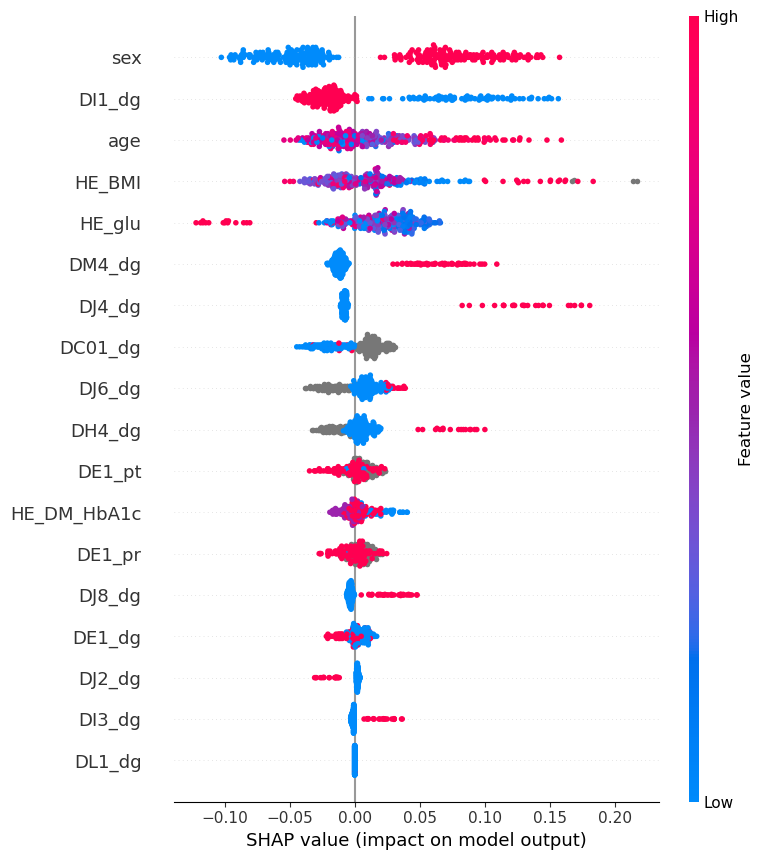

In [138]:
# =========================================================
# Analysis 2-1 Random forest 및 SHAP
# Predictor의 NaN은 그대로 유지
# 표준화하지 않음
# =========================================================

result_analysis2_1_rf_shap = run_rf_shap_analysis(
    data=analysis2_1_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 2-1: ASCVD군 LDL-C <55 mg/dL 미달성 "
        "- Random forest and SHAP"
    ),
    predictor_cols=analysis2_1_predictors,
    run_shap=True,
    random_state=42
)

In [139]:
# =========================================================
# Analysis 2-2 분석 대상 생성
# ASCVD + Diabetes군
# 0 = LDL-C <55 mg/dL 목표 달성
# 1 = LDL-C >=55 mg/dL 목표 미달성
# =========================================================

analysis2_2_df = analysis_df[
    (
        analysis_df["Disease"]
        == "ASCVD + Diabetes"
    )
    &
    (
        analysis_df["HE_LDL_drct"].notna()
    )
].copy()


analysis2_2_df["Outcome_NotAchieved"] = np.where(
    analysis2_2_df["HE_LDL_drct"] >= 55,
    1,
    0
)


# Analysis 2-2 Predictor 설정
analysis2_2_predictors = [
    col for col in base_predictors
    if col not in [
        "DI5_dg",
        "DI6_dg",
        "DE1_ag",
        "DE1_pr",
        "DE1_pt"
    ]
    and col not in lipid_cols
    and col not in di2_cols
]

In [140]:
# =========================================================
# Analysis 2-2 Logistic regression
# 결측치는 함수 내부에서 대체
# 연속형 변수는 표준화
# =========================================================

result_analysis2_2_logistic = run_logistic_analysis(
    data=analysis2_2_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 2-2: ASCVD + Diabetes군 "
        "LDL-C <55 mg/dL 미달성 "
        "- Logistic regression"
    ),
    predictor_cols=analysis2_2_predictors,
    continuous_cols=continuous_cols
)

Logistic regression에서 상수라 제외된 변수: ['HE_DM_HbA1c']

Analysis 2-2: ASCVD + Diabetes군 LDL-C <55 mg/dL 미달성 - Logistic regression
분석 대상자 수: 134
목표 달성: 20명 (14.93%)
목표 미달성: 114명 (85.07%)

Multivariable logistic regression:
    Feature            OR  CI_95_Lower  CI_95_Upper  p_value  Direction
0    HE_glu  5.489000e-01       0.3257       0.9250   0.0243  미달성 오즈 감소
1    DJ2_dg  1.491000e-01       0.0185       1.2039   0.0741  미달성 오즈 감소
2    DI3_dg  2.603100e+00       0.4230      16.0202   0.3021  미달성 오즈 증가
3    HE_BMI  1.242300e+00       0.6906       2.2348   0.4689  미달성 오즈 증가
4    DI1_dg  8.038000e-01       0.2142       3.0167   0.7462  미달성 오즈 감소
5    DM4_dg  1.292700e+00       0.2017       8.2835   0.7865  미달성 오즈 증가
6       age  9.423000e-01       0.5380       1.6505   0.8354  미달성 오즈 감소
7    DL1_dg  7.268000e-01       0.0305      17.3277   0.8436  미달성 오즈 감소
8    DJ8_dg  1.203800e+00       0.1321      10.9707   0.8693  미달성 오즈 증가
9    DE1_dg  1.029900e+00       0.2294       4.6228   0.9694  미

/var/folders/7w/hw9rw9p16vn9z7jggjqtl6_w0000gn/T/ipykernel_11082/1359608434.py:260: RuntimeWarning: overflow encountered in exp
  "CI_95_Upper": np.exp(


RF에서 상수라 제외된 변수: ['DE1_dg']

Analysis 2-2: ASCVD + Diabetes군 LDL-C <55 mg/dL 미달성 - Random forest and SHAP
분석 대상자 수: 108

Predictor별 결측치 수:
DC01_dg    71
DJ6_dg     37
DH4_dg     37
HE_BMI      2
sex         0
age         0
DI1_dg      0
DI3_dg      0
DJ2_dg      0
DJ4_dg      0
DL1_dg      0
DJ8_dg      0
DM4_dg      0
HE_glu      0
dtype: int64

Random forest 변수 중요도:
    Feature  Importance
0    HE_BMI      0.3028
1       age      0.2418
2    HE_glu      0.2232
3    DJ6_dg      0.0424
4    DM4_dg      0.0333
5    DH4_dg      0.0316
6       sex      0.0294
7    DI1_dg      0.0241
8    DI3_dg      0.0212
9   DC01_dg      0.0205
10   DJ4_dg      0.0143
11   DJ8_dg      0.0131
12   DJ2_dg      0.0024
13   DL1_dg      0.0000

SHAP 변수 중요도:
    Feature  Mean_Abs_SHAP
0    HE_BMI         0.0680
1    HE_glu         0.0379
2       age         0.0348
3    DM4_dg         0.0102
4    DJ6_dg         0.0099
5    DI1_dg         0.0092
6       sex         0.0085
7    DH4_dg         0.0076
8    DI3_dg 

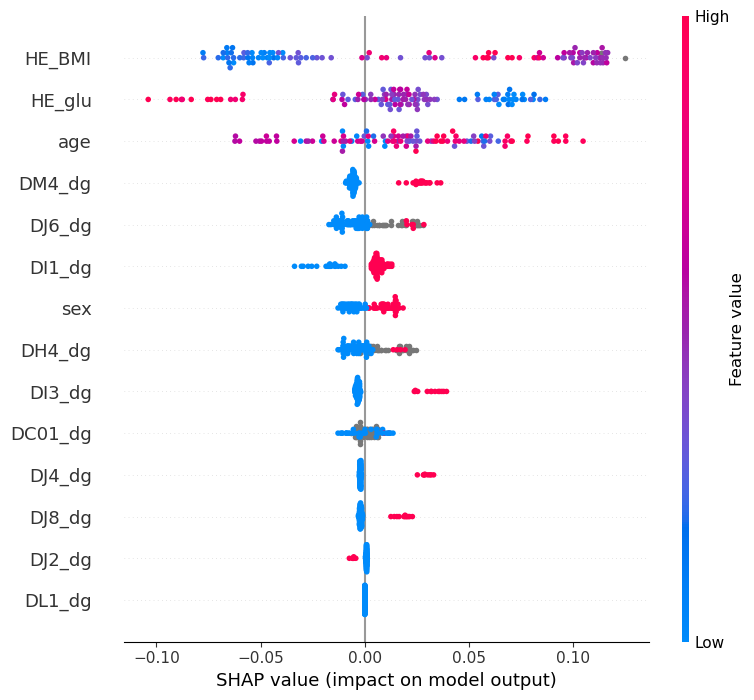

In [64]:
# =========================================================
# Analysis 2-2 Random forest 및 SHAP
# Predictor의 NaN은 그대로 유지
# 표준화하지 않음
# =========================================================

result_analysis2_2_rf_shap = run_rf_shap_analysis(
    data=analysis2_2_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 2-2: ASCVD + Diabetes군 "
        "LDL-C <55 mg/dL 미달성 "
        "- Random forest and SHAP"
    ),
    predictor_cols=analysis2_2_predictors,
    run_shap=True,
    random_state=42
)


Analysis 3: 전체 대상자 LDL-C <130 mg/dL 미달성 - Logistic regression
분석 대상자 수: 9,198
목표 달성: 6,007명 (65.31%)
목표 미달성: 3,191명 (34.69%)

Multivariable logistic regression:
    Feature      OR  CI_95_Lower  CI_95_Upper  p_value  Direction
0    DI1_dg  0.2350       0.2093       0.2638   0.0000  미달성 오즈 감소
1       age  0.5495       0.5174       0.5836   0.0000  미달성 오즈 감소
2    HE_glu  1.2050       1.1287       1.2864   0.0000  미달성 오즈 증가
3    DJ4_dg  0.6704       0.4989       0.9009   0.0080  미달성 오즈 감소
4    DI6_dg  0.5386       0.3391       0.8553   0.0087  미달성 오즈 감소
5       sex  1.1434       1.0238       1.2770   0.0175  미달성 오즈 증가
6    DI5_dg  0.4319       0.1982       0.9411   0.0346  미달성 오즈 감소
7   DC01_dg  0.6308       0.4053       0.9817   0.0412  미달성 오즈 감소
8    DM4_dg  0.8143       0.6630       1.0003   0.0503  미달성 오즈 감소
9    HE_BMI  0.9475       0.8972       1.0006   0.0524  미달성 오즈 감소
10   DE1_dg  0.2543       0.0241       2.6812   0.2546  미달성 오즈 감소
11   DJ6_dg  0.9134       0.7125       1.1710 

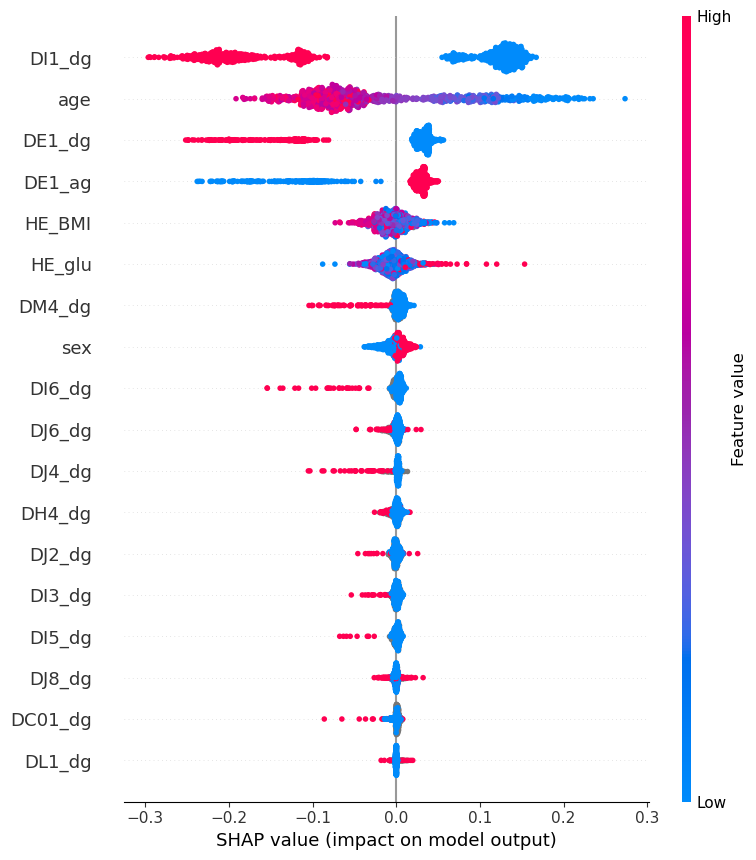

In [74]:
# =========================================================
# Analysis 3 분석 대상 생성
# 전체 대상자
# 0 = LDL-C <130 mg/dL 목표 달성
# 1 = LDL-C >=130 mg/dL 목표 미달성
# =========================================================

analysis3_df = analysis_df[
    analysis_df["HE_LDL_drct"].notna()
].copy()


analysis3_df["Outcome_NotAchieved"] = np.where(
    analysis3_df["HE_LDL_drct"] >= 130,
    1,
    0
)


# =========================================================
# Analysis 3에서 사용할 Predictor를 새롭게 정의
# =========================================================

analysis3_predictors = [
    "sex",
    "age",
    "DI1_dg",
    "DI3_dg",
    "DI5_dg",
    "DI6_dg",
    "DJ2_dg",
    "DC01_dg",
    "DJ4_dg",
    "DL1_dg",
    "DJ8_dg",
    "DM4_dg",
    "DJ6_dg",
    "DH4_dg",
    "DE1_dg",
    "DE1_ag",
    "HE_BMI",
    "HE_glu"
]


# Analysis 3 연속형 변수
analysis3_continuous_cols = [
    "age",
    "HE_BMI",
    "HE_glu"
]


# =========================================================
# Analysis 3 Logistic regression
# =========================================================

result_analysis3_logistic = run_logistic_analysis(
    data=analysis3_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 3: 전체 대상자 "
        "LDL-C <130 mg/dL 미달성 "
        "- Logistic regression"
    ),
    predictor_cols=analysis3_predictors,
    continuous_cols=analysis3_continuous_cols
)


# =========================================================
# Analysis 3 Random forest 및 SHAP
# =========================================================

result_analysis3_rf_shap = run_rf_shap_analysis(
    data=analysis3_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 3: 전체 대상자 "
        "LDL-C <130 mg/dL 미달성 "
        "- Random forest and SHAP"
    ),
    predictor_cols=analysis3_predictors,
    run_shap=True,
    random_state=42
)

In [71]:
# =========================================================
# Analysis 3 분석 대상 생성
# 전체 대상자
# 0 = LDL-C <130 mg/dL 목표 달성
# 1 = LDL-C >=130 mg/dL 목표 미달성
# =========================================================


analysis3_df = analysis_df[
    analysis_df["HE_LDL_drct"].notna()
].copy()


analysis3_df["Outcome_NotAchieved"] = np.where(
    analysis3_df["HE_LDL_drct"] >= 130,
    1,
    0
)


# Analysis 3 Predictor 설정

exclude_cols = [
    "Outcome_NotAchieved",
    "HE_LDL_drct",
    "HE_chol",
    "HE_HDL_st2",
    "HE_TG",
    "HE_HCHOL",
    "LDL_130_Achieved",
    
]

analysis3_predictors = [
    col for col in analysis3_df.columns
    if col not in exclude_cols
    and col not in di2_cols
]

In [72]:
# =========================================================
# Analysis 3 Logistic regression
# 결측치는 함수 내부에서 대체
# 연속형 변수는 표준화
# =========================================================

result_analysis3_logistic = run_logistic_analysis(
    data=analysis3_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 3: 전체 대상자 "
        "LDL-C <130 mg/dL 미달성 "
        "- Logistic regression"
    ),
    predictor_cols=analysis3_predictors,
    continuous_cols=continuous_cols
)

Logistic regression에서 전부 결측이라 제외된 변수: ['ID', 'Patient_Group', 'Disease']

Analysis 3: 전체 대상자 LDL-C <130 mg/dL 미달성 - Logistic regression
분석 대상자 수: 9,198
목표 달성: 6,007명 (65.31%)
목표 미달성: 3,191명 (34.69%)

Multivariable logistic regression:
             Feature           OR  CI_95_Lower  CI_95_Upper  p_value  \
0   LDL_130_Achieved       0.0000          0.0          inf   0.9989   
1              ASCVD  361195.6943          0.0          inf   1.0000   
2         TARGET_LDL       1.1861          0.0          inf   1.0000   
3                sex       1.0000          0.0          inf   1.0000   
4             DE1_pt       1.0000          0.0          inf   1.0000   
5            DC01_dg       1.0000          0.0          inf   1.0000   
6                age       1.0000          0.0          inf   1.0000   
7             HE_BMI       1.0000          0.0          inf   1.0000   
8             DM4_dg       1.0000          0.0          inf   1.0000   
9             DJ6_dg       1.0000          0.

/opt/miniconda3/envs/lab/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/lab/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/lab/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/envs/lab/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified


RF에서 전부 결측이라 제외된 변수: ['ID', 'Patient_Group', 'Disease']

Analysis 3: 전체 대상자 LDL-C <130 mg/dL 미달성 - Random forest and SHAP
분석 대상자 수: 9,198

Predictor별 결측치 수:
DC01_dg             7272
DE1_pr              7083
DE1_pt              7083
DJ2_dg              4019
DM4_dg              4018
DI5_dg              4018
DI6_dg              4018
DI3_dg              4015
DJ6_dg              2571
DH4_dg              2571
HE_HTG              1010
DL1_dg               645
DJ8_dg               645
DJ4_dg               644
HE_obe               185
HE_BMI               164
TARGET_LDL             0
LDL_130_Achieved       0
year                   0
ASCVD                  0
sex                    0
age                    0
DN1_dg                 0
HE_glu                 0
DE1_ag                 0
DE1_dg                 0
DI1_dg                 0
Diabetes               0
dtype: int64

Random forest 변수 중요도:
             Feature  Importance
0   LDL_130_Achieved      0.7614
1             DI1_dg      0.0799
2       

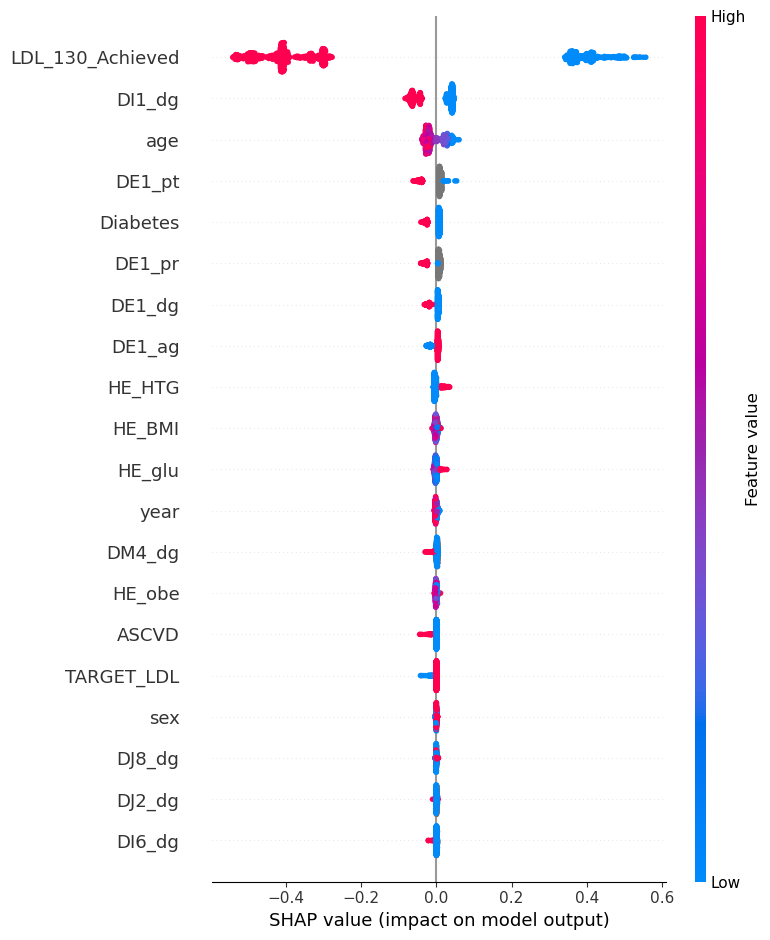

In [73]:
# =========================================================
# Analysis 3 Random forest 및 SHAP
# Predictor의 NaN은 그대로 유지
# 표준화하지 않음
# =========================================================

result_analysis3_rf_shap = run_rf_shap_analysis(
    data=analysis3_df,
    outcome_col="Outcome_NotAchieved",
    analysis_name=(
        "Analysis 3: 전체 대상자 "
        "LDL-C <130 mg/dL 미달성 "
        "- Random forest and SHAP"
    ),
    predictor_cols=analysis3_predictors,
    run_shap=True,
    random_state=42
)

In [ ]:
import sys

print(sys.executable)

In [12]:
analysis_df.to_csv("NEW_Foranalysis.csv",index=False)

In [13]:
# ==========================================================
# ASCVD (LDL-C 결측 제외)
# ==========================================================

ascvd_df = analysis_df[
    (analysis_df["ASCVD"] == 1) &
    (analysis_df["HE_LDL_drct"].notna())
]

print("=" * 50)
print("ASCVD")
print(f"표본수 (N)        : {len(ascvd_df)}")
print(f"LDL-C 평균        : {ascvd_df['HE_LDL_drct'].mean():.2f} mg/dL")
print(f"LDL-C 표준편차(SD): {ascvd_df['HE_LDL_drct'].std():.2f} mg/dL")


# ==========================================================
# ASCVD + Diabetes (LDL-C 결측 제외)
# ==========================================================

ascvd_dm_df = analysis_df[
    (analysis_df["ASCVD"] == 1) &
    (analysis_df["Diabetes"] == 1) &
    (analysis_df["HE_LDL_drct"].notna())
]

print("\n" + "=" * 50)
print("ASCVD + Diabetes")
print(f"표본수 (N)        : {len(ascvd_dm_df)}")
print(f"LDL-C 평균        : {ascvd_dm_df['HE_LDL_drct'].mean():.2f} mg/dL")
print(f"LDL-C 표준편차(SD): {ascvd_dm_df['HE_LDL_drct'].std():.2f} mg/dL")

ASCVD
표본수 (N)        : 296
LDL-C 평균        : 87.56 mg/dL
LDL-C 표준편차(SD): 35.27 mg/dL

ASCVD + Diabetes
표본수 (N)        : 108
LDL-C 평균        : 77.82 mg/dL
LDL-C 표준편차(SD): 24.48 mg/dL


In [14]:
# ==========================================================
# ASCVD 중 LDL-C 목표 미달성자
# ==========================================================

ascvd_unachieved_df = analysis_df[
    (analysis_df["ASCVD"] == 1) &
    (analysis_df["HE_LDL_drct"].notna()) &
    (analysis_df["TARGET_LDL"].notna()) &
    (analysis_df["HE_LDL_drct"] >= analysis_df["TARGET_LDL"])
]

print("=" * 50)
print("ASCVD - LDL-C 목표 미달성자")
print(f"표본수 (N)         : {len(ascvd_unachieved_df)}")
print(f"LDL-C 평균         : {ascvd_unachieved_df['HE_LDL_drct'].mean():.2f} mg/dL")
print(f"LDL-C 표준편차(SD) : {ascvd_unachieved_df['HE_LDL_drct'].std():.2f} mg/dL")


# ==========================================================
# ASCVD + Diabetes 중 LDL-C 목표 미달성자
# ==========================================================

ascvd_dm_unachieved_df = analysis_df[
    (analysis_df["ASCVD"] == 1) &
    (analysis_df["Diabetes"] == 1) &
    (analysis_df["HE_LDL_drct"].notna()) &
    (analysis_df["TARGET_LDL"].notna()) &
    (analysis_df["HE_LDL_drct"] >= analysis_df["TARGET_LDL"])
]

print("\n" + "=" * 50)
print("ASCVD + Diabetes - LDL-C 목표 미달성자")
print(f"표본수 (N)         : {len(ascvd_dm_unachieved_df)}")
print(f"LDL-C 평균         : {ascvd_dm_unachieved_df['HE_LDL_drct'].mean():.2f} mg/dL")
print(f"LDL-C 표준편차(SD) : {ascvd_dm_unachieved_df['HE_LDL_drct'].std():.2f} mg/dL")

ASCVD - LDL-C 목표 미달성자
표본수 (N)         : 255
LDL-C 평균         : 94.39 mg/dL
LDL-C 표준편차(SD) : 33.15 mg/dL

ASCVD + Diabetes - LDL-C 목표 미달성자
표본수 (N)         : 92
LDL-C 평균         : 83.60 mg/dL
LDL-C 표준편차(SD) : 21.64 mg/dL
